In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [4]:
nav = pd.read_csv("../Data/02_nav_history.csv")

fund = pd.read_csv("../Data/01_fund_master.csv")

benchmark = pd.read_csv("../Data/10_benchmark_indices.csv")

In [5]:
import pandas as pd

# Load datasets
fund = pd.read_csv("../Data/01_fund_master.csv")

nav = pd.read_csv("../Data/02_nav_history.csv")

benchmark = pd.read_csv("../Data/10_benchmark_indices.csv")

In [6]:
print("Fund Master:", fund.shape)
print("NAV History:", nav.shape)
print("Benchmark:", benchmark.shape)

print("\nFund Master")
display(fund.head())

print("\nNAV History")
display(nav.head())

print("\nBenchmark")
display(benchmark.head())

Fund Master: (40, 15)
NAV History: (46000, 3)
Benchmark: (8050, 3)

Fund Master


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02



NAV History


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692



Benchmark


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [7]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [8]:
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

In [9]:
# Calculate daily returns for each mutual fund
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [10]:
# Display the first 10 rows
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [11]:
# Summary statistics of daily returns
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

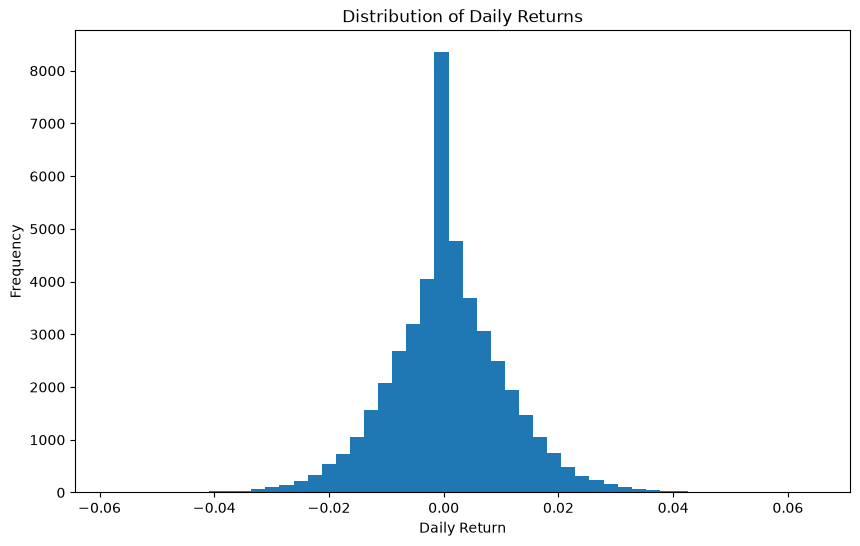

In [12]:
plt.figure(figsize=(10,6))

plt.hist(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [13]:
# Save the updated NAV dataset
nav.to_csv("../Data/02_nav_history.csv", index=False)

In [14]:
# Check the date range
print("Start Date :", nav["date"].min())
print("End Date   :", nav["date"].max())

Start Date : 2022-01-03 00:00:00
End Date   : 2026-05-29 00:00:00


In [15]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

In [16]:
# Last date available in the dataset
end_date = nav["date"].max()

# Date one year before
start_date_1y = end_date - pd.DateOffset(years=1)

# List to store results
cagr_1y = []

# Calculate CAGR for each fund
for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    # Closest NAV to the start date
    start_row = group[group["date"] >= start_date_1y].head(1)

    # Latest NAV
    end_row = group.tail(1)

    if len(start_row) > 0 and len(end_row) > 0:

        start_nav = start_row["nav"].values[0]
        end_nav = end_row["nav"].values[0]

        cagr = calculate_cagr(start_nav, end_nav, 1)

        cagr_1y.append({
            "amfi_code": amfi_code,
            "CAGR_1Y": cagr
        })

# Convert to DataFrame
cagr_1y = pd.DataFrame(cagr_1y)

In [17]:
cagr_1y.head()

,amfi_code,CAGR_1Y
0,100016,-0.022243
1,100025,0.037050
2,100033,0.532324
3,101206,0.479241
4,101207,-0.239860


In [18]:
# Date three years before
start_date_3y = end_date - pd.DateOffset(years=3)

# List to store results
cagr_3y = []

# Calculate CAGR for each fund
for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    # Closest NAV to the start date
    start_row = group[group["date"] >= start_date_3y].head(1)

    # Latest NAV
    end_row = group.tail(1)

    if len(start_row) > 0 and len(end_row) > 0:

        start_nav = start_row["nav"].values[0]
        end_nav = end_row["nav"].values[0]

        cagr = calculate_cagr(start_nav, end_nav, 3)

        cagr_3y.append({
            "amfi_code": amfi_code,
            "CAGR_3Y": cagr
        })

# Convert to DataFrame
cagr_3y = pd.DataFrame(cagr_3y)

In [19]:
cagr_3y.head()

,amfi_code,CAGR_3Y
0,100016,0.012926
1,100025,0.039164
2,100033,0.324425
3,101206,0.289677
4,101207,-0.041524


In [20]:
# Date five years before
start_date_5y = end_date - pd.DateOffset(years=5)

# List to store results
cagr_5y = []

# Calculate CAGR for each fund
for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    # Closest NAV to the start date
    start_row = group[group["date"] >= start_date_5y].head(1)

    # Latest NAV
    end_row = group.tail(1)

    if len(start_row) > 0 and len(end_row) > 0:

        start_nav = start_row["nav"].values[0]
        end_nav = end_row["nav"].values[0]

        cagr = calculate_cagr(start_nav, end_nav, 5)

        cagr_5y.append({
            "amfi_code": amfi_code,
            "CAGR_5Y": cagr
        })

# Convert to DataFrame
cagr_5y = pd.DataFrame(cagr_5y)

In [21]:
cagr_5y.head()

,amfi_code,CAGR_5Y
0,100016,0.023168
1,100025,0.039127
2,100033,0.260741
3,101206,0.204427
4,101207,0.069533


In [22]:
# Merge all CAGR tables
cagr_table = cagr_1y.merge(cagr_3y, on="amfi_code")
cagr_table = cagr_table.merge(cagr_5y, on="amfi_code")

# Add fund names
cagr_table = cagr_table.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Rearrange columns
cagr_table = cagr_table[
    [
        "amfi_code",
        "scheme_name",
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]
]

# Display first 10 rows
cagr_table.head(10)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022243,0.012926,0.023168
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037050,0.039164,0.039127
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,0.260741
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,0.204427
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,0.069533
5,101208,ABSL Liquid Fund - Regular - Growth,0.072366,0.063158,0.057057
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.202077,0.196673,0.158788
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.167975,-0.007674,0.010303
8,102887,UTI Flexi Cap Fund - Regular - Growth,0.135831,0.255562,0.146781
9,118632,Nippon India Large Cap Fund - Regular - Growth,0.339810,0.226524,0.208811


In [23]:
# Sort funds by 5-Year CAGR (Highest to Lowest)
cagr_table = cagr_table.sort_values(
    by="CAGR_5Y",
    ascending=False
)

# Reset index
cagr_table = cagr_table.reset_index(drop=True)

# Display top 10 funds
cagr_table.head(10)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,120505,ICICI Pru Midcap Fund - Regular - Growth,0.296047,0.317775,0.283768
1,119598,SBI Small Cap Fund - Regular Plan - Growth,0.827761,0.266699,0.280332
2,149324,DSP Small Cap Fund - Regular - Growth,0.651387,0.270004,0.279174
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.397518,0.291789,0.276299
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.203607,0.340009,0.267993
5,120843,Kotak Flexicap Fund - Regular - Growth,0.266571,0.295828,0.267425
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,0.260741
7,149323,DSP Midcap Fund - Regular - Growth,0.214812,0.268700,0.256118
8,119094,Axis Midcap Fund - Regular - Growth,0.222611,0.351118,0.244453
9,119551,SBI Bluechip Fund - Regular Plan - Growth,0.604373,0.304565,0.223849


In [24]:
# Save CAGR comparison table
cagr_table.to_csv("../Reports/cagr_comparison.csv", index=False)

print("CAGR comparison table saved successfully!")

CAGR comparison table saved successfully!


In [25]:
# Annual Risk-Free Rate (6.5%)
risk_free_rate = 0.065

# Convert annual rate to daily rate
daily_rf = risk_free_rate / 252

print("Annual Risk-Free Rate :", risk_free_rate)
print("Daily Risk-Free Rate  :", daily_rf)

Annual Risk-Free Rate : 0.065
Daily Risk-Free Rate  : 0.00025793650793650796


In [26]:
# Calculate Sharpe Ratio for each fund

sharpe_list = []

for amfi_code, group in nav.groupby("amfi_code"):

    # Remove missing daily returns
    returns = group["daily_return"].dropna()

    # Skip funds with insufficient data
    if len(returns) < 2:
        continue

    # Average daily return
    mean_return = returns.mean()

    # Daily standard deviation
    std_return = returns.std()

    # Sharpe Ratio (Annualized)
    sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)

    sharpe_list.append({
        "amfi_code": amfi_code,
        "Sharpe_Ratio": sharpe
    })

# Convert to DataFrame
sharpe_df = pd.DataFrame(sharpe_list)

In [27]:
# Add scheme names
sharpe_df = sharpe_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Sort by Sharpe Ratio (Highest to Lowest)
sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
).reset_index(drop=True)

# Display Top 10 funds
sharpe_df.head(10)

,amfi_code,Sharpe_Ratio,scheme_name
0,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
1,120843,1.306744,Kotak Flexicap Fund - Regular - Growth
2,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
3,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth
4,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth
5,149323,1.132122,DSP Midcap Fund - Regular - Growth
6,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
7,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth
8,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
9,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [28]:
# Save Sharpe Ratio table
sharpe_df.to_csv("../Reports/sharpe_ratio.csv", index=False)

print("Sharpe Ratio table saved successfully!")

Sharpe Ratio table saved successfully!


In [29]:
# Calculate Sortino Ratio

sortino_list = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        continue

    # Average daily return
    mean_return = returns.mean()

    # Negative returns only
    downside_returns = returns[returns < 0]

    # Skip if no downside returns
    if len(downside_returns) == 0:
        continue

    # Downside deviation
    downside_std = downside_returns.std()

    # Annualized Sortino Ratio
    sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)

    sortino_list.append({
        "amfi_code": amfi_code,
        "Sortino_Ratio": sortino
    })

# Convert to DataFrame
sortino_df = pd.DataFrame(sortino_list)

In [30]:
# Add scheme names
sortino_df = sortino_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Sort by Sortino Ratio
sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
).reset_index(drop=True)

# Display Top 10 funds
sortino_df.head(10)

,amfi_code,Sortino_Ratio,scheme_name
0,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
1,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
2,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
3,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
4,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth
5,149323,1.875101,DSP Midcap Fund - Regular - Growth
6,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth
7,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
8,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
9,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth


In [31]:
# Save Sortino Ratio table
sortino_df.to_csv("../Reports/sortino_ratio.csv", index=False)

print("Sortino Ratio table saved successfully!")

Sortino Ratio table saved successfully!


In [32]:
# Check benchmark dataset
print(benchmark.head())

print("\nColumns:")
print(benchmark.columns)

print("\nShape:")
print(benchmark.shape)

        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
3 2022-01-06    NIFTY50     17878.51
4 2022-01-07    NIFTY50     17759.15

Columns:
Index(['date', 'index_name', 'close_value'], dtype='str')

Shape:
(8050, 3)


In [33]:
# Check benchmark dataset
print(benchmark.head())

print("\nColumns:")
print(benchmark.columns)

print("\nShape:")
print(benchmark.shape)

        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
3 2022-01-06    NIFTY50     17878.51
4 2022-01-07    NIFTY50     17759.15

Columns:
Index(['date', 'index_name', 'close_value'], dtype='str')

Shape:
(8050, 3)


In [34]:
# Sort benchmark data
benchmark = benchmark.sort_values(["index_name", "date"])

# Calculate benchmark daily returns
benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
             .pct_change()
)

# Display first few rows
benchmark.head(10)

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726
3455,2022-01-10,BSE_SMALLCAP,26476.06,0.006049
3456,2022-01-11,BSE_SMALLCAP,26462.96,-0.000495
3457,2022-01-12,BSE_SMALLCAP,26090.99,-0.014056
3458,2022-01-13,BSE_SMALLCAP,26085.36,-0.000216
3459,2022-01-14,BSE_SMALLCAP,26081.45,-0.000150


In [35]:
# Select only NIFTY100 benchmark
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

# Keep only required columns
nifty100 = nifty100[["date", "benchmark_return"]]

# Remove missing values
nifty100 = nifty100.dropna()

# Display first 5 rows
nifty100.head()

,date,benchmark_return
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150
1155,2022-01-10,-0.008351


In [36]:
alpha_beta = []

for amfi_code, group in nav.groupby("amfi_code"):

    # Keep only required columns
    fund_returns = group[["date", "daily_return"]].dropna()

    # Merge with NIFTY100 returns
    merged = pd.merge(
        fund_returns,
        nifty100,
        on="date",
        how="inner"
    )

    # Need enough observations
    if len(merged) < 30:
        continue

    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": amfi_code,
        "Alpha": intercept * 252,   # Annualized Alpha
        "Beta": slope,
        "R_Squared": r_value ** 2
    })

# Convert to DataFrame
alpha_beta_df = pd.DataFrame(alpha_beta)

In [37]:
# Add scheme names
alpha_beta_df = alpha_beta_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Rearrange columns
alpha_beta_df = alpha_beta_df[
    [
        "amfi_code",
        "scheme_name",
        "Alpha",
        "Beta",
        "R_Squared"
    ]
]

# Sort by Alpha (Highest to Lowest)
alpha_beta_df = alpha_beta_df.sort_values(
    by="Alpha",
    ascending=False
).reset_index(drop=True)

# Display Top 10 funds
alpha_beta_df.head(10)

,amfi_code,scheme_name,Alpha,Beta,R_Squared
0,119598,SBI Small Cap Fund - Regular Plan - Growth,0.303370,-0.023196,1.414258e-04
1,149324,DSP Small Cap Fund - Regular - Growth,0.300579,0.011455,3.532991e-05
2,120505,ICICI Pru Midcap Fund - Regular - Growth,0.292636,0.000549,1.345534e-07
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.282704,0.018134,1.748889e-04
4,120843,Kotak Flexicap Fund - Regular - Growth,0.273305,-0.022830,3.430543e-04
5,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104,1.206652e-05
6,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.269838,0.023684,4.625437e-04
7,149323,DSP Midcap Fund - Regular - Growth,0.265986,-0.002523,3.357978e-06
8,119094,Axis Midcap Fund - Regular - Growth,0.260767,-0.066265,1.936879e-03
9,119551,SBI Bluechip Fund - Regular Plan - Growth,0.232010,-0.031751,8.869789e-04


In [38]:
# Save Alpha & Beta table
alpha_beta_df.to_csv("../Reports/alpha_beta.csv", index=False)

print("Alpha & Beta table saved successfully!")

Alpha & Beta table saved successfully!


In [39]:
max_dd_list = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    # Maximum Drawdown
    max_dd = group["drawdown"].min()

    # Worst drawdown date
    worst_row = group.loc[group["drawdown"].idxmin()]

    max_dd_list.append({
        "amfi_code": amfi_code,
        "Maximum_Drawdown": max_dd,
        "Worst_Date": worst_row["date"]
    })

# Convert to DataFrame
max_dd_df = pd.DataFrame(max_dd_list)

In [40]:
# Add scheme names
max_dd_df = max_dd_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Rearrange columns
max_dd_df = max_dd_df[
    [
        "amfi_code",
        "scheme_name",
        "Maximum_Drawdown",
        "Worst_Date"
    ]
]

# Sort by Maximum Drawdown
# (Less negative = Better)
max_dd_df = max_dd_df.sort_values(
    by="Maximum_Drawdown",
    ascending=False
).reset_index(drop=True)

# Display Top 10 funds
max_dd_df.head(10)

,amfi_code,scheme_name,Maximum_Drawdown,Worst_Date
0,120507,ICICI Pru Liquid Fund - Regular - Growth,-0.000977,2025-10-20
1,120844,Kotak Liquid Fund - Regular - Growth,-0.001163,2024-04-30
2,101208,ABSL Liquid Fund - Regular - Growth,-0.001622,2023-09-12
3,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,2023-07-28
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.043287,2025-04-01
5,118636,Nippon India Gilt Securities Fund - Regular - ...,-0.083164,2024-02-09
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,-0.108599,2022-03-29
7,148567,Mirae Asset Large Cap Fund - Regular - Growth,-0.112657,2023-10-20
8,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-07-05
9,118635,Nippon India ETF Nifty 50 BeES,-0.116506,2022-06-09


In [41]:
# Save Maximum Drawdown table
max_dd_df.to_csv("../Reports/max_drawdown.csv", index=False)

print("Maximum Drawdown table saved successfully!")

Maximum Drawdown table saved successfully!


In [42]:
print(fund.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [43]:
print(fund.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [44]:
# Create base scorecard
scorecard = cagr_table[["amfi_code", "scheme_name", "CAGR_3Y"]].copy()

# Add Sharpe Ratio
scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code"
)

# Add Alpha
scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code"
)

# Add Expense Ratio
scorecard = scorecard.merge(
    fund[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code"
)

# Add Maximum Drawdown
scorecard = scorecard.merge(
    max_dd_df[["amfi_code", "Maximum_Drawdown"]],
    on="amfi_code"
)

In [45]:
# Higher is better
scorecard["Return_Rank"] = scorecard["CAGR_3Y"].rank(ascending=False)
scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)
scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)

# Lower expense ratio is better
scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

# Smaller drawdown (less negative) is better
scorecard["Drawdown_Rank"] = scorecard["Maximum_Drawdown"].rank(ascending=False)

n = len(scorecard)

# Convert ranks to scores (0-100)
scorecard["Return_Score"] = (n - scorecard["Return_Rank"]) / (n - 1) * 100
scorecard["Sharpe_Score"] = (n - scorecard["Sharpe_Rank"]) / (n - 1) * 100
scorecard["Alpha_Score"] = (n - scorecard["Alpha_Rank"]) / (n - 1) * 100
scorecard["Expense_Score"] = (n - scorecard["Expense_Rank"]) / (n - 1) * 100
scorecard["Drawdown_Score"] = (n - scorecard["Drawdown_Rank"]) / (n - 1) * 100

In [46]:
# Calculate weighted final score

scorecard["Fund_Score"] = (
    scorecard["Return_Score"] * 0.30 +
    scorecard["Sharpe_Score"] * 0.25 +
    scorecard["Alpha_Score"] * 0.20 +
    scorecard["Expense_Score"] * 0.15 +
    scorecard["Drawdown_Score"] * 0.10
)

# Sort by final score
scorecard = scorecard.sort_values(
    by="Fund_Score",
    ascending=False
).reset_index(drop=True)

# Display Top 10 Funds
scorecard[
    [
        "amfi_code",
        "scheme_name",
        "Fund_Score"
    ]
].head(10)

,amfi_code,scheme_name,Fund_Score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,85.897436
1,120505,ICICI Pru Midcap Fund - Regular - Growth,81.794872
2,120843,Kotak Flexicap Fund - Regular - Growth,81.538462
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.256410
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,79.487179
5,119094,Axis Midcap Fund - Regular - Growth,76.410256
6,119551,SBI Bluechip Fund - Regular Plan - Growth,74.166667
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,73.012821
8,101206,ABSL Frontline Equity Fund - Regular - Growth,67.371795
9,119598,SBI Small Cap Fund - Regular Plan - Growth,66.538462


In [47]:
# Save Fund Scorecard
scorecard.to_csv("../Reports/fund_scorecard.csv", index=False)

print("Fund Scorecard saved successfully!")

Fund Scorecard saved successfully!
